# **Predictive Banking Marketing Intelligence**

### **Introduction**

Direct marketing campaigns can be costly when many customer contacts do not result in a successful response. Data-driven targeting can help organizations focus their resources on customers who show stronger potential for conversion.

This project uses the **UCI Bank Marketing dataset** to develop a machine-learning approach for predicting term-deposit subscription and supporting customer prioritization. The analysis combines exploratory analysis, customer segmentation, supervised classification, customer ranking, lift and gains analysis, and resource-allocation analysis.

The final goal is to translate model predictions into a practical marketing strategy that helps the bank determine who should be contacted first and how far down the prioritized contact list the campaign should continue. An interactive Streamlit dashboard is also developed to present the targeting strategy and its estimated business impact.

### **Case Study**

A Portuguese bank uses direct marketing campaigns, primarily telephone calls, to promote term deposits to its customers. However, customer response is relatively low. In the cleaned data used for this project, only 11.27% of recorded contacts resulted in a term-deposit subscription. This means that a large portion of marketing calls do not result in a subscription.

Each call requires agent time and operational resources. Contacting every available customer without prioritization can therefore lead to unnecessary calls and inefficient use of the marketing team's resources. At the same time, reducing the number of calls without a clear targeting strategy could cause the bank to miss customers who may be interested in subscribing.

The bank therefore needs a more data-driven way to decide *who should be contacted first and how far down the customer list the campaign should continue*.

Historical customer characteristics, previous campaign interactions, and economic information can be used to estimate subscription potential before a call is made. Customers can then be ranked according to their predicted likelihood of subscribing, allowing the bank to focus its calling resources on higher-priority contacts.

The analysis will also evaluate different calling depths. This is important because expanding the campaign may reach additional subscribers, but each additional group of customers also requires more calls and increases campaign cost.

### **Business Problem:**  

**Which customers should the bank prioritize for its term-deposit campaign, and how many customers should it contact before the additional calls provide limited business value?**

The goal is therefore not simply to build an accurate prediction model, but to translate the model results into a practical marketing strategy that helps the bank *reach more potential subscribers with fewer unnecessary calls and better allocation of marketing resources*.


### **Project Objective**

The objective of this project is to develop a predictive customer-targeting approach that helps the bank use its marketing resources more efficiently.

The analysis will:

- understand customer and campaign patterns associated with term-deposit subscription;
- identify meaningful customer segments using unsupervised learning;
- build classification models using information available before the call;
- estimate each customer's probability of subscribing;
- rank customer contacts from highest to lowest predicted probability;
- evaluate different probability thresholds and calling depths;
- compare model-based targeting with random customer selection; and
- recommend a practical calling depth based on customer ranking, lift, gains, and resource efficiency.



### **Dataset Overview**

The project uses the Bank Marketing dataset from the UCI Machine Learning Repository. The data was collected from direct marketing campaigns conducted by a Portuguese banking institution. The campaigns were primarily conducted through telephone calls.

Source : UCI Machine Learning Repository. (2012). Bank Marketing Dataset. UCI Bank Marketing Dataset https://archive.ics.uci.edu/dataset/222/bank+marketing

The original dataset contains 41,188 records, with customer characteristics, financial information, campaign history, previous campaign information, economic indicators, and the final subscription outcome.

The target variable is **`y`**, which indicates whether the customer subscribed to a term deposit:

| Target Value | Meaning |
|:---|:---|
| `yes` | Customer subscribed to a term deposit |
| `no` | Customer did not subscribe |

In the cleaned modeling data used in this project, approximately **11.27%** of the recorded contacts resulted in a subscription, showing that the target is imbalanced.

*Unit of analysis:* Each row represents a recorded marketing contact. It should not automatically be interpreted as a unique customer.



### **Data Dictionary**

The original variables can be grouped into five main categories: *customer characteristics, financial characteristics, current campaign information, previous campaign information, and economic conditions.*

### Customer Characteristics

| Variable | Description |
|:---|:---|
| `age` | Age of the customer |
| `job` | Type of employment |
| `marital` | Marital status |
| `education` | Education level |

### Financial Characteristics

| Variable | Description |
|:---|:---|
| `default` | Whether the customer has credit in default |
| `housing` | Whether the customer has a housing loan |
| `loan` | Whether the customer has a personal loan |

### Current Campaign Information

| Variable | Description |
|:---|:---|
| `contact` | Type of communication used to contact the customer |
| `month` | Month of the current campaign contact |
| `day_of_week` | Day of the week of the current contact |
| `duration` | Duration of the current telephone call, in seconds |
| `campaign` | Number of contacts made during the current campaign for the customer |

### Previous Campaign Information

| Variable | Description |
|:---|:---|
| `pdays` | Number of days since the customer was last contacted in a previous campaign |
| `previous` | Number of contacts made before the current campaign |
| `poutcome` | Outcome of the previous marketing campaign |

### Economic Conditions

| Variable | Description |
|:---|:---|
| `emp.var.rate` | Employment variation rate |
| `cons.price.idx` | Consumer price index |
| `cons.conf.idx` | Consumer confidence index |
| `euribor3m` | Three-month Euribor interest rate |
| `nr.employed` | Number of employees |

### Target Variable

| Variable | Description |
|:---|:---|
| `y` | Whether the customer subscribed to a term deposit (`yes` or `no`) |



### *Important Data Considerations*

Before beginning the analysis, two variables require special attention because using them incorrectly could affect the validity of the results.

- `duration` – Potential Data Leakage

- `duration` measures how long the telephone call lasted. It may be strongly related to whether a customer eventually subscribes, but the value is only known after the call has taken place.

The business goal of this project is to decide which customers should be prioritized before making the call. Therefore, `duration` would not be available when the bank makes its targeting decision.

 **Decision:** `duration` will be excluded from predictive modeling to prevent data leakage and ensure that the model represents a realistic pre-call decision.

- `pdays = 999` – Special Value

The variable `pdays` measures the number of days since a customer was last contacted in a previous campaign. However, the value `999` has a special meaning: the customer was not previously contacted.

Treating `999` as an actual number of days would incorrectly suggest that the customer was contacted 999 days ago.

 **Decision:** Previous-contact history will be represented separately so that customers who were never previously contacted can be distinguished from customers with an actual previous contact.



## **Main Business Question**

 **How can customer and previous campaign information be used to predict term-deposit subscription and help the bank prioritize customers for more efficient marketing?**



### **Research Questions**

**1 – Subscription Drivers**

**Which customer, financial, campaign, previous-campaign, and economic characteristics are most associated with term-deposit subscription?**

This question helps identify patterns that may explain why some customers are more responsive to the campaign than others.

**2 – Customer Segmentation**

**Can customers be grouped into meaningful segments, and do those segments differ in their characteristics, previous campaign behavior, and subscription rates?**

This question provides a broader understanding of different types of customers before individual subscription probabilities are predicted.

**3 – Subscription Prediction**

**How accurately can machine-learning models predict whether a customer will subscribe using information available before the call?**

Different classification models will be compared to determine which provides the strongest predictive performance.

**4 – Classification Threshold**

**Which prediction threshold provides the best balance between identifying potential subscribers and avoiding unnecessary classification errors?**

Different probability thresholds will be evaluated using precision, recall, and F1-score. This threshold is used for classification evaluation, while the final contact strategy is based on ranking customers by predicted subscription probability.

**5 – Targeting Effectiveness**

**How much better is model-based targeting than randomly selecting customers to contact?**

Lift and cumulative gains analysis will be used to determine whether ranking customers by predicted probability allows the bank to identify more subscribers with fewer calls.

**6 – Calling Strategy**

**How far down the ranked customer list should the bank call?**

Different calling depths will be evaluated using customer ranking, lift, cumulative gains, and the number of calls required. The final recommendation will focus on identifying a practical, resource-efficient calling depth. Illustrative cost and subscriber-value assumptions are explored separately in the Streamlit dashboard as planning scenarios.


### **Analytical Approach**

The project follows a structured approach that moves from understanding the customer data to developing a practical marketing strategy. Each stage builds on the findings from the previous stage.

| **Stage** | **Analysis** | **What Will Be Done** | **Why It Is Needed** |
|---|---|---|---|
| **1** | **Data Preparation and Quality Assessment** | Review the dataset, data types, missing or unknown values, duplicates, unusual values, target distribution, and potential data leakage. | Ensures the data is reliable and that only information available before the call is used for prediction. |
| **2** | **Exploratory Data Analysis (EDA)** | Examine customer, financial, campaign, previous-campaign, and economic variables and compare them with subscription behavior. | Identifies important patterns and provides an initial understanding of factors associated with subscription. |
| **3** | **Feature Engineering** | Transform or create useful variables, including previous-contact indicators, days since previous contact, age groups, and campaign-related features. | Makes important customer and campaign information easier for the models to use and interpret. |
| **4** | **Final Feature Analysis** | Re-examine important variables and engineered features after data preparation. | Confirms that the final features are meaningful and suitable for further analysis and modeling. |
| **5** | **Customer Segmentation** | Apply K-Means clustering, select an appropriate number of clusters, and profile the resulting customer segments. | Determines whether customers form meaningful groups with different characteristics, previous-campaign behavior, and subscription rates. |
| **6** | **Train/Test Split and Model Preprocessing** | Separate the data into training and testing sets and prepare numerical and categorical variables for machine learning. | Keeps the final test data separate and ensures that models are trained and evaluated fairly. |
| **7** | **Supervised Classification Modeling** | Train and compare Logistic Regression, Decision Tree, Random Forest, and XGBoost models. | Determines which model is most effective at predicting customer subscription probability before the call. |
| **8** | **Model Evaluation and Tuning** | Evaluate models using appropriate classification and probability-based metrics and tune the strongest models. | Identifies a reliable model without relying only on accuracy, which can be misleading because subscriptions are relatively uncommon. |
| **9** | **Threshold Optimization** | Test different probability thresholds and compare precision, recall, and F1-score. | Evaluates the classification trade-off at different probability cutoffs without treating the threshold as the final contact strategy. |
| **10** | **Customer Ranking, Lift, and Gains Analysis** | Rank customers by predicted subscription probability and compare model-based targeting with random customer selection. | Measures whether the model can identify more potential subscribers within a smaller portion of the calling list. |
| **11** | **Calling-Depth and Resource Allocation Analysis** | Evaluate different calling depths using lift, cumulative gains, subscribers reached, calls required, and calls avoided. | Identifies a practical calling depth that reaches a large share of subscribers while reducing unnecessary calls. |
| **12** | **Model Explainability** | Review feature importance from the final Random Forest model. | Identifies which variables contribute most to the model's predictions without implying that they cause subscription. |
| **13** | **Streamlit Business Dashboard** | Develop an interactive dashboard showing customer prioritization, subscription drivers, calling depth, campaign outcomes, and illustrative financial scenarios. | Converts the analysis into an easy-to-use decision-support tool and allows users to explore how different targeting and planning assumptions affect estimated outcomes. |
| **14** | **Business Recommendation** | Combine customer insights, model predictions, customer ranking, lift, gains, and calling-depth analysis into a final targeting strategy. | Provides a practical recommendation about who should be contacted first and how many contacts should be prioritized. |

### **Expected Business Outcome**

The project therefore moves beyond simply predicting whether a customer will subscribe. The final goal is to turn the model results into a *practical customer-targeting strategy* that helps the bank prioritize stronger prospects, reduce unnecessary calls, and use its marketing resources more efficiently.

The final approach will allow the bank to:

- estimate subscription probability for each customer contact;
- rank customer contacts according to predicted subscription potential;
- recommend a practical calling depth;
- compare targeted calling with random selection; and
- use marketing resources more efficiently by focusing calls on contacts with stronger predicted potential.

The supervised model will therefore support the final business decision: **who should be contacted first and how far down the prioritized contact list should the bank call?**

The Streamlit dashboard converts the model results into an interactive decision-support tool for marketing teams.

Users can:

- select the percentage of contacts to target;
- view historical subscribers reached and calls avoided;
- compare targeting effectiveness with random selection;
- explore estimated campaign value under user-defined cost and subscriber-value assumptions;
- review the highest-priority contacts; and
- download the selected priority contact list.

# Data Analysis and Modeling

## Dependencies and Imports

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

## Data Loading 

In [44]:
df = pd.read_csv('bank-additional-full.csv', sep = ';')
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Exploratory Data Analysis

In [45]:
df.info() # shows no nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

<b> Analysis and Explanation: </b><br>
The dataset contains 41,188 records and 21 columns: 20 predictors and the target variable, y. Every column has 41,188 non-null entries, so there are no null values recorded in the DataFrame

The duration feature records the length of the call in seconds. Our model is intended to prioritize customers before a call is placed, so call duration would not be available when making a prediction. Including it would introduce data leakage: the model would learn from information collected after the decision it is meant to support. We will exclude duration from the predictive features.

In [46]:
category_summary = (
    df.select_dtypes(include = ["object", "string"])
      .melt(var_name = "column", value_name = "value")
      .groupby(["column", "value"], dropna=False)
      .size()
      .reset_index(name = "count")
)

category_summary["percent"] = (
    category_summary["count"]
    / category_summary.groupby("column")["count"].transform("sum")
    * 100
).round(1)

category_summary = category_summary.sort_values(
    ["column", "count"], ascending=[True, False]
)

category_summary

,column,value,count,percent
0,contact,cellular,26144,63.5
1,contact,telephone,15044,36.5
4,day_of_week,thu,8623,20.9
3,day_of_week,mon,8514,20.7
6,day_of_week,wed,8134,19.7
5,day_of_week,tue,8090,19.6
2,day_of_week,fri,7827,19.0
7,default,no,32588,79.1
8,default,unknown,8597,20.9
9,default,yes,3,0.0


<b>Analysis and Explanation: </b><br>
Although every column is non-null, six categorical columns contain the value <b>"unknown"</b>: default, education, housing, loan, job, and marital. It appears most often in default, with 8,597 records (20.9%), followed by education, with 1,731 records (4.2%). The other four columns each have "unknown" in fewer than 3% of records.

We will keep <b>"unknown"</b> as a separate category rather than replace it with "no" or remove those records. This preserves the information that the value was unavailable, especially in default, where "unknown" accounts for 20.9% of records.

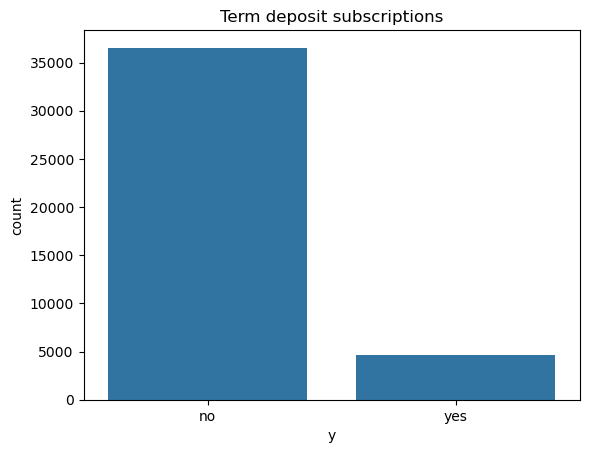

In [47]:
counts = df["y"].value_counts()
percentages = df["y"].value_counts(normalize = True).mul(100).round(1)

pd.DataFrame({"count": counts, "percent": percentages})

sns.countplot(data = df, x= "y", order=["no", "yes"])
plt.title("Term deposit subscriptions")
plt.show()

<b> Analysis and Explanation: </b><br>
Of the 41,188 recorded contacts, 36,548 (88.7%) did not result in a term deposit subscription, while 4,640 (11.3%) did. The chart shows that "no" is much more common than "yes", so the target variable is imbalanced.

## Numeric Predictor Overview

In [48]:
df.drop(columns="duration").describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


<b>Analysis and Explanation </b><br>
Customers have a median age of 38. Most had few current-campaign contacts (median 2), though the maximum of 56 suggests a long upper tail. At least 75% had no prior-campaign contacts (previous = 0). The pdays quartiles are all 999, a code for no previous contact, so its mean should not be read as a typical number of days. The remaining columns summarize economic conditions on different scales.

## Investigating pdays

In [49]:
df["pdays"].value_counts().head(10)

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
Name: count, dtype: int64

In [50]:
print(
    "Percent with pdays = 999:",
    round((df["pdays"] == 999).mean() * 100, 1)
)

Percent with pdays = 999: 96.3


<b>Analysis and Explanation </b><br>
In 96.3% of records, pdays = 999, indicating no contact in a previous campaign. Only 3.7% have a recorded number of days since prior contact. This explains why all three quartiles are 999 and why the mean does not represent a meaningful waiting time.

## Feature Engineering: pdays

In [51]:
df_model = df.copy()

# 1 = contacted in a previous campaign; 0 = not contacted
df_model["previously_contacted"] = (df_model["pdays"] != 999).astype(int)

# Keep actual day counts; use 0 where no prior contact exists
df_model["days_since_previous_contact"] = (
    df_model["pdays"].where(df_model["pdays"] != 999, 0)
)

df_model = df_model.drop(columns="pdays")

df_model[["previously_contacted", "days_since_previous_contact"]].head()

,previously_contacted,days_since_previous_contact
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0


<b>Analysis and Explanation </b><br>
Because pdays = 999 means no contact in a previous campaign, we replaced pdays with two features. previously_contacted records whether a prior contact occurred, while days_since_previous_contact retains the day count when one is available. This prevents the model from interpreting 999 as an actual number of days.

## Age and Contact Distributions

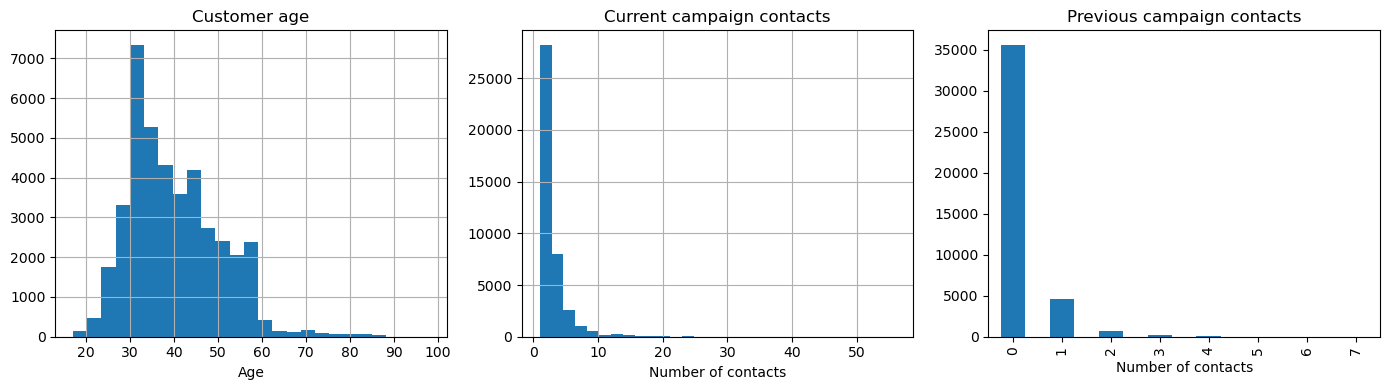

In [52]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4))

df_model["age"].hist(bins = 25, ax=axes[0])
axes[0].set_title("Customer age")
axes[0].set_xlabel("Age")

df_model["campaign"].hist(bins = 30, ax = axes[1])
axes[1].set_title("Current campaign contacts")
axes[1].set_xlabel("Number of contacts")

df_model["previous"].value_counts().sort_index().plot.bar(ax = axes[2])
axes[2].set_title("Previous campaign contacts")
axes[2].set_xlabel("Number of contacts")

plt.tight_layout()
plt.show()

<b>Analysis and Explanation</b><br>
Most recorded customers are between roughly 30 and 60 years old, with relatively few at older ages. Current-campaign contacts are strongly right-skewed: most records involve only a few contacts, while a small number involve many more. Previous-campaign contacts are concentrated at zero, consistent with the earlier finding that most records have no prior contact history. These plots show unusual high contact counts, but do not establish that those values are errors.

## Predictor Correlations

In [53]:
X_eda = df_model.drop(columns = ["y", "duration"])

# One-hot encode categorical columns for this EDA calculation
X_eda = pd.get_dummies(X_eda, dtype=int)

y_eda = (df_model["y"] == "yes").astype(int)

scores = X_eda.corrwith(y_eda)

ranked_scores = scores.reindex(
    scores.abs().sort_values(ascending=False).index
).round(3)

print(ranked_scores.to_string())

nr.employed                     -0.355
previously_contacted             0.325
poutcome_success                 0.316
euribor3m                       -0.308
emp.var.rate                    -0.298
days_since_previous_contact      0.267
previous                         0.230
poutcome_nonexistent            -0.194
contact_cellular                 0.145
contact_telephone               -0.145
month_mar                        0.144
month_oct                        0.137
cons.price.idx                  -0.136
month_sep                        0.126
month_may                       -0.108
default_no                       0.099
default_unknown                 -0.099
job_student                      0.094
job_retired                      0.092
month_dec                        0.079
month_apr                        0.076
job_blue-collar                 -0.074
campaign                        -0.066
cons.conf.idx                    0.055
marital_single                   0.054
education_university.degr

<b>Explanation and Analysis</b>
The strongest individual associations with subscription are nr.employed (−0.355), previously_contacted (0.325), poutcome_success (0.316), euribor3m (−0.308), and emp.var.rate (−0.298). This shows that prior campaign history and economic conditions are prominent in the correlation results.

days_since_previous_contact has a positive correlation of 0.267, but that score also reflects the placeholder value of zero assigned to records with no prior contact. Most demographic and loan categories have correlations close to zero. Each score describes one encoded feature on its own; it does not show whether that feature will improve a predictive model.

## Feature Engineering
*Feature engineering and EDA #2 by Mason Delan*

This builds on df_model from EDA #1, which already has the pdays split. The cell below:

1. Removes the 12 exact duplicate rows from our proposal, before dropping duration so only true copies count
2. Makes y 1 for yes and 0 for no, and drops duration since it is only known after the call
3. Merges default = yes (3 rows) into unknown and education = illiterate (18 rows) into basic.4y, since they are too small to use
4. Adds age_group, since age had only a 0.030 correlation with y even though students and retirees subscribe the most (raw age stays for tree models)
5. Caps campaign at 10, since it is very right skewed (median 2, max 56) and EDA #1 found no sign the high counts are errors

I did not add the financial obligation indicator from our framework, since housing and loan were close to 0 correlation with y in EDA #1.

In [54]:
# remove exact duplicates first, while duration is still there
print("Exact duplicate rows:", df_model.duplicated().sum())
df_model = df_model.drop_duplicates().reset_index(drop=True)

# target as 1 and 0, and duration removed
df_model["y"] = (df_model["y"] == "yes").astype(int)
df_model = df_model.drop(columns="duration")

# merge categories that are almost empty
df_model["default"] = df_model["default"].replace("yes", "unknown")
df_model["education"] = df_model["education"].replace("illiterate", "basic.4y")

# age groups
age_bins = [0, 24, 39, 59, 120]
age_labels = ["under 25", "25 to 39", "40 to 59", "60 and over"]
df_model["age_group"] = pd.cut(df_model["age"], bins=age_bins, labels=age_labels)

# cap campaign at 10
print("Rows with more than 10 contacts:", (df_model["campaign"] > 10).sum())
df_model["campaign_capped"] = df_model["campaign"].clip(upper=10)
df_model = df_model.drop(columns="campaign")

print("Shape:", df_model.shape)
print(f"Subscription rate: {df_model['y'].mean() * 100:.2f}%")

Exact duplicate rows: 12
Rows with more than 10 contacts: 869
Shape: (41176, 22)
Subscription rate: 11.27%


<b>Analysis and Explanation</b><br>
df_model now has 41,176 rows, 21 predictors, and y, and the subscription rate stays at 11.27%. Only 869 rows had more than 10 contacts, so the cap barely changes the data. Encoding and scaling are left for after the split, fit on the training data only.

## EDA #2
EDA #2 checks if the new features are related to subscribing, if any features overlap too much, and if there is anything the train and test split should know.

age_group
under 25       24.0
25 to 39       11.1
40 to 59        8.8
60 and over    39.6
Name: y, dtype: float64
campaign_capped
1     13.0
2     11.5
3     10.7
4      9.4
5      7.5
6      7.7
7      6.0
8      4.2
9      6.0
10     3.6
Name: y, dtype: float64


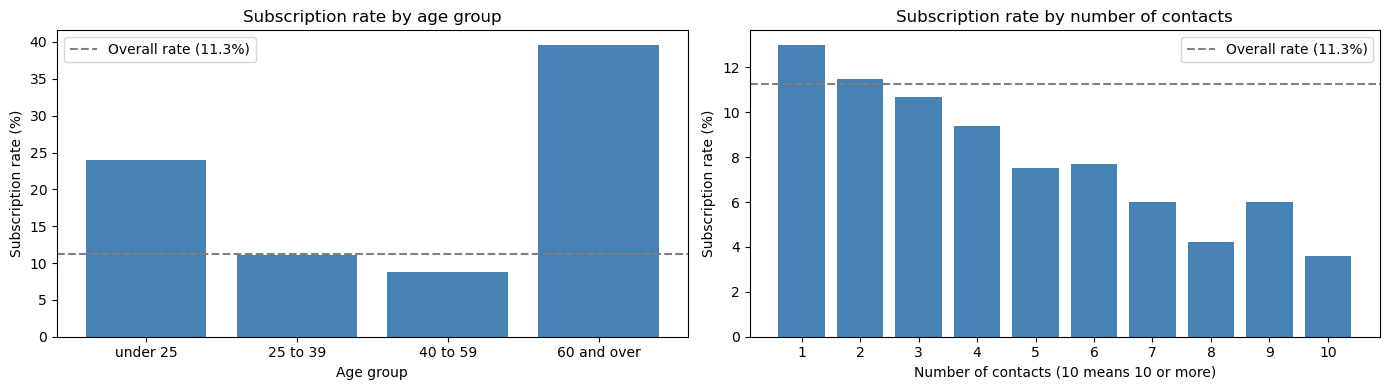

In [55]:
# subscription rate by age group and by number of contacts
overall_rate = df_model["y"].mean() * 100
age_rate = (df_model.groupby("age_group", observed=True)["y"].mean() * 100).round(1)
contact_rate = (df_model.groupby("campaign_capped")["y"].mean() * 100).round(1)
print(age_rate)
print(contact_rate)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(age_rate.index.astype(str), age_rate, color="steelblue")
axes[0].set_title("Subscription rate by age group")
axes[0].set_xlabel("Age group")
axes[1].bar(contact_rate.index.astype(str), contact_rate, color="steelblue")
axes[1].set_title("Subscription rate by number of contacts")
axes[1].set_xlabel("Number of contacts (10 means 10 or more)")
for ax in axes:
    ax.axhline(overall_rate, color="gray", linestyle="--",
               label=f"Overall rate ({overall_rate:.1f}%)")
    ax.set_ylabel("Subscription rate (%)")
    ax.legend()
plt.tight_layout()
plt.show()

<b>Analysis and Explanation</b><br>
Age is high at both ends and low in the middle (24.0% under 25 and 39.6% at 60 and over, versus 11.1% and 8.8% in between), which is why age barely correlated with y in EDA #1. The rate also mostly drops as contacts go up, from 13.0% at one contact to 3.6% at 10 or more. That matters for when to stop calling, though customers who need many calls may just be less interested.

In [56]:
# how previously_contacted lines up with poutcome
prev = df_model.groupby(["poutcome", "previously_contacted"])["y"].agg(["count", "mean"])
prev.columns = ["rows", "rate"]
prev["rate"] = (prev["rate"] * 100).round(1)
print(prev)
print("Rows with previous above 0:", (df_model["previous"] > 0).sum())
print("Rows with previously_contacted = 1:", df_model["previously_contacted"].sum())

                                   rows  rate
poutcome    previously_contacted             
failure     0                      4110  12.9
            1                       142  51.4
nonexistent 0                     35551   8.8
success     1                      1373  65.1
Rows with previous above 0: 5625
Rows with previously_contacted = 1: 1515


<b>Analysis and Explanation</b><br>
EDA #1 treated pdays = 999 as no previous contact. But 5,625 rows have previous above 0 and only 1,515 have previously_contacted = 1, because 4,110 customers from failed earlier campaigns still have pdays = 999. So previously_contacted really means the bank has a date for the last contact (mostly previous successes, 1,373 of 1,515). Previous successes still subscribe at 65.1%, versus 8.8% for customers with no earlier campaign.

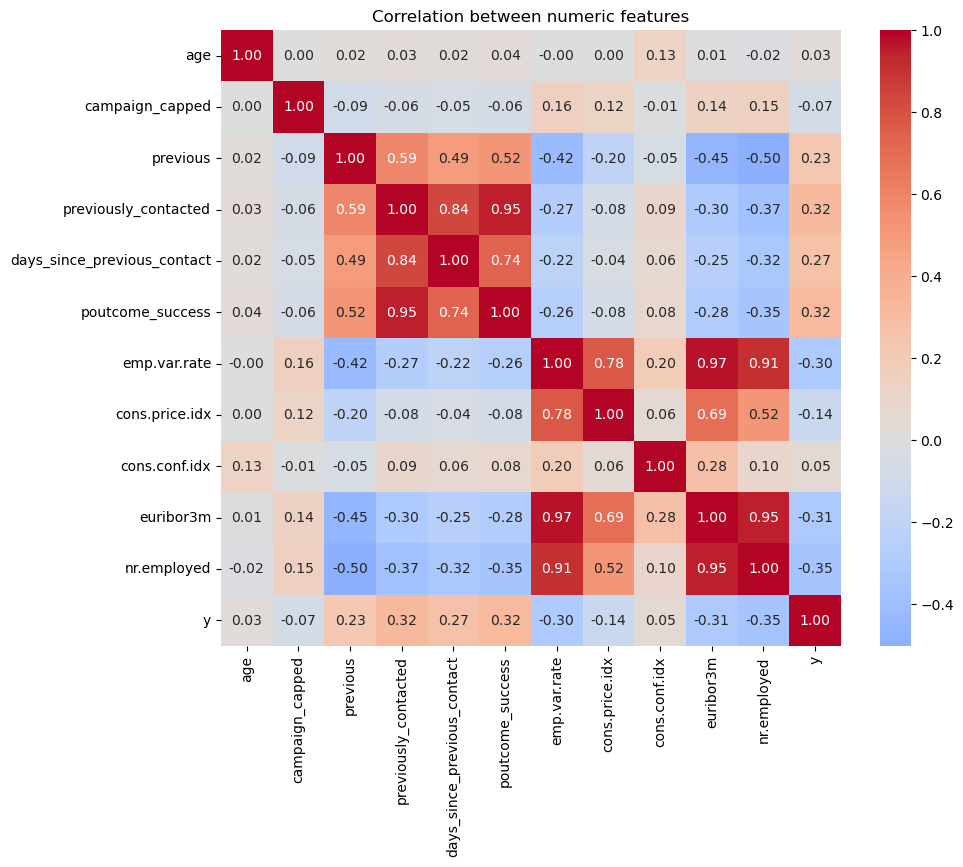

In [57]:
# correlation between the numeric features
corr_data = df_model.copy()
corr_data["poutcome_success"] = (corr_data["poutcome"] == "success").astype(int)

corr_cols = ["age", "campaign_capped", "previous", "previously_contacted",
             "days_since_previous_contact", "poutcome_success", "emp.var.rate",
             "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "y"]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between numeric features")
plt.show()

<b>Analysis and Explanation</b><br>
Two groups of features move almost together:

* Economic: emp.var.rate, euribor3m, and nr.employed (0.91 to 0.97)
* Previous campaign: previously_contacted with poutcome_success (0.95) and days_since_previous_contact (0.84)

All five of the strongest features from EDA #1 are in these groups, so some of that signal is repeated. For logistic regression we should keep only one economic variable (nr.employed is strongest with y at -0.35). Tree models are not hurt as much.

In [58]:
# the rows are in date order, so five equal parts in order work like five time periods
time_part = pd.qcut(df_model.index, 5, labels=["1st", "2nd", "3rd", "4th", "5th"])
time_table = df_model.groupby(time_part, observed=True).agg(
    rate=("y", "mean"), euribor3m=("euribor3m", "mean"))
time_table["rate"] = (time_table["rate"] * 100).round(1)
time_table.round(2)

,rate,euribor3m
1st,3.1,4.86
2nd,5.4,4.95
3rd,5.9,4.90
4th,11.1,2.36
5th,30.8,1.03


<b>Analysis and Explanation</b><br>
The UCI data is ordered over time from May 2008 to November 2010. The subscription rate and economic conditions change across this period, suggesting that the economic variables may partly reflect when a contact occurred. These variables are retained because they are available before the call and may provide useful predictive information. However, their time-related nature should be considered when interpreting model results. Time-based validation can be explored in future work to evaluate how well the model generalizes to later campaign periods.

In [59]:
# save the engineered dataset for the train and test split step
print("Missing values:", df_model.isna().sum().sum())
df_model.to_csv("bank_features.csv", index=False)

Missing values: 0


## Summary and Notes for the Next Steps

* bank_features.csv (same as df_model): 41,176 rows, 21 predictors, and y (11.27% subscribed)
* Encode and scale after the split, fit on the training data only, and stratify on y
* For logistic regression, keep only one of emp.var.rate, euribor3m, and nr.employed
* previously_contacted = 0 does not mean never contacted, just no recorded date
* Time-based validation can be considered as future work to evaluate model stability across campaign periods.

# **Unsupervised Learning – Customer Segmentation**

The supervised-learning part of this project will predict which individual customers are more likely to subscribe to a term deposit. Before prediction, clustering is used as an exploratory step to see whether customers form broad groups based on demographic, financial, and previous-campaign information.

K-Means clustering is performed without using the subscription target (y). After the clusters are created, their characteristics and subscription rates are compared. This helps us understand what information is driving the customer grouping and whether the groups provide useful business context.

**Questions explored in this section**

1. Can customers be grouped based on their demographic, financial, and previous-campaign characteristics?

   This checks whether the selected customer characteristics create broad groups in the data.

2. How many customer groups are supported by the tested K-Means solutions?

   The Elbow Method and Silhouette Score are used to compare values of k from 2 to 8.

3. What characteristics distinguish the identified groups?

   Cluster profiling is used to understand which variables are mainly responsible for the separation.

4. How does previous campaign behavior differ across the groups?

   Previous campaign information is examined because earlier EDA showed a strong relationship with subscription.

5. Do the groups have different term-deposit subscription rates?

   The target is not used to create the clusters, but subscription rates are compared afterward for business interpretation.

**Business Purpose**

Clustering is used as a supporting analysis, not as a replacement for supervised learning. Its purpose is to explore customer structure and identify the main characteristics that separate broad groups. The supervised model will later be used for the more important business task of predicting and ranking individual customer contacts.

### **Clustering Preprocessing**

The target y is not used in clustering because the goal is to form groups without using the final subscription outcome. After the groups are created, subscription rates can be compared for interpretation.

The selected clustering variables include customer characteristics and previous-campaign information. Because some previous-campaign variables are closely related, we will also check after clustering whether they strongly drive the final groups.

Before applying K-Means, we need to decide which variables actually describe meaningful differences between customers.Not every variable used for prediction should automatically be used for clustering. Including irrelevant or inappropriate variables can create clusters that are mathematically different but not useful to the bank.

**Define the clustering feature set**

The target variable y is excluded so that K-Means does not use the final subscription outcome when creating the groups. The clustering features include demographic, financial, and previous-campaign information because the goal is to explore customer profiles. After clustering, we will profile the groups carefully to see which variables are actually driving the separation.

In [60]:
#Select Features for Customer Segmentation
cluster_features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "previously_contacted",
    "days_since_previous_contact",
    "previous",
    "poutcome"
]

# Create a separate clustering dataset so that df_model remains
# unchanged for the supervised modeling stage later.
X_cluster = df_model[cluster_features].copy()

print("Clustering dataset shape:", X_cluster.shape)

print("\nSelected clustering features:")
for col in X_cluster.columns:
    print(col)

print("\nPreview:")
display(X_cluster.head())

Clustering dataset shape: (41176, 11)

Selected clustering features:
age
job
marital
education
default
housing
loan
previously_contacted
days_since_previous_contact
previous
poutcome

Preview:


,age,job,marital,education,default,housing,loan,previously_contacted,days_since_previous_contact,previous,poutcome
0,56,housemaid,married,basic.4y,no,no,no,0,0,0,nonexistent
1,57,services,married,high.school,unknown,no,no,0,0,0,nonexistent
2,37,services,married,high.school,no,yes,no,0,0,0,nonexistent
3,40,admin.,married,basic.6y,no,no,no,0,0,0,nonexistent
4,56,services,married,high.school,no,no,yes,0,0,0,nonexistent



age, job, marital, and education describe the customer's demographic profile.
default, housing, and loan provide information about the customer's financial situation.
previously_contacted, days_since_previous_contact, previous, and poutcome describe the customer's prior relationship with bank campaigns.

 The subscription target (y) was excluded so that the clusters could be formed independently of whether a customer subscribed. This allows the analysis to first identify naturally occurring customer groups and then compare their subscription behavior afterward.

**Separate numerical and categorical variables**

Numerical and categorical variables require different preprocessing before K-Means can calculate distances.
- Numerical variables will be standardized.
- Categorical variables will be one-hot encoded.

In [61]:
# Numerical and categorical features for clustering
numeric_cluster_features = [
    "age",
    "days_since_previous_contact",
    "previous"
]

categorical_cluster_features = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "previously_contacted",
    "poutcome"
]

print("Numerical clustering features:")
print(numeric_cluster_features)

print("\nCategorical clustering features:")
print(categorical_cluster_features)

Numerical clustering features:
['age', 'days_since_previous_contact', 'previous']

Categorical clustering features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'previously_contacted', 'poutcome']


**Build the clustering preprocessing pipeline**

K-Means is distance-based. StandardScaler prevents numerical variables with larger ranges from dominating the clustering.
Categories such as job and education do not have a meaningful numerical order. One-hot encoding converts them into binary indicators without imposing an artificial ranking.

In [62]:
cluster_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cluster_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_cluster_features
        )
    ]
)

# Fit and transform only the features selected for segmentation.
X_cluster_processed = cluster_preprocessor.fit_transform(X_cluster)

print("Original clustering dataset shape:",X_cluster.shape)

print("Processed clustering dataset shape:",X_cluster_processed.shape)

print("Any NaN:", np.isnan(X_cluster_processed).any(), "| Any inf:", np.isinf(X_cluster_processed).any())

Original clustering dataset shape: (41176, 11)
Processed clustering dataset shape: (41176, 39)
Any NaN: False | Any inf: False


After preprocessing, the 11 original variables were converted into 39 numerical features because categorical variables were expanded through one-hot encoding. Numerical variables were standardized so that differences in scale would not dominate the K-Means distance calculations. The final clustering dataset contains all 41,176 customers with no missing or infinite values, confirming that the data is ready for clustering.

**Selecting the Number of Customer Clusters**

Here we test several possible values of k and compare their statistical quality.

In [63]:
# Test cluster solutions from 2 through 8 clusters
k_values = range(2, 9)

# Create empty lists to store evaluation results for each k
inertia_scores = []
silhouette_scores = []

# Fit a separate K-Means model for each possible number of clusters
for k in k_values:

    # Create the K-Means model for the current number of clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit the model and assign each customer to a cluster
    cluster_labels = kmeans.fit_predict(X_cluster_processed)

    # Store the inertia for the current cluster solution
    inertia_scores.append(kmeans.inertia_)

    # Calculate and store the silhouette score for the current cluster solution
    silhouette_scores.append(
        silhouette_score(
            X_cluster_processed,
            cluster_labels
        )
    )

# Combine the evaluation results into a table for comparison
cluster_selection_results = pd.DataFrame({
    "Number_of_Clusters": list(k_values),
    "Inertia": inertia_scores,
    "Silhouette_Score": silhouette_scores
})

# Display the results rounded to four decimal places
cluster_selection_results.round(4)

,Number_of_Clusters,Inertia,Silhouette_Score
0,2,226101.5150,0.3581
1,3,195126.3887,0.1449
2,4,172091.9007,0.1590
3,5,161174.3035,0.1277
4,6,154041.7371,0.1201
5,7,146438.6352,0.1315
6,8,140874.9404,0.1242


**Elbow Method**

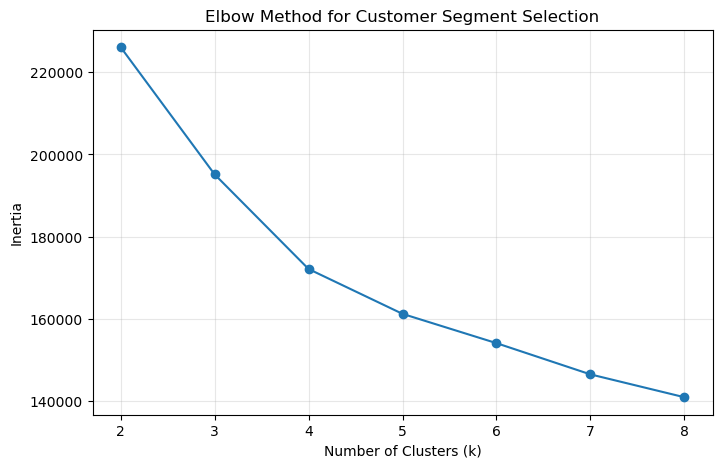

In [64]:
# Create a new figure for the inertia plot
plt.figure(figsize=(8, 5))

# Plot the number of clusters on the x-axis and the corresponding
# inertia calculated for each K-Means model on the y-axis
plt.plot(
    cluster_selection_results["Number_of_Clusters"],
    cluster_selection_results["Inertia"],
    marker="o"
)

# Label the axes to show what is being compared
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

# Add a descriptive title to the chart
plt.title("Elbow Method for Customer Segment Selection")

# Display every tested value of k on the x-axis
plt.xticks(cluster_selection_results["Number_of_Clusters"])

# Add grid lines to make changes in inertia easier to compare
plt.grid(alpha=0.3)

# Display the completed elbow plot
plt.show()

**Silhouette Score**

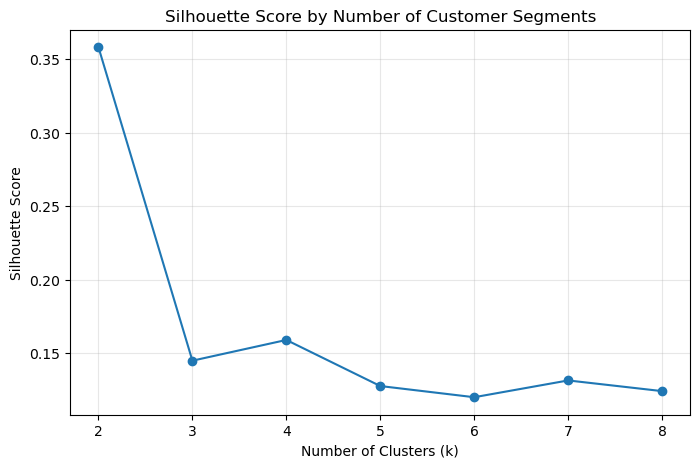

In [65]:
# Create a new figure for the silhouette-score plot
plt.figure(figsize=(8, 5))

# Plot each tested number of clusters against its corresponding
# silhouette score calculated in the previous step
plt.plot(
    cluster_selection_results["Number_of_Clusters"],
    cluster_selection_results["Silhouette_Score"],
    marker="o"
)

# Label the axes to identify the two values being compared
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")

# Add a descriptive title to the chart
plt.title("Silhouette Score by Number of Customer Segments")

# Display every tested value of k on the x-axis
plt.xticks(cluster_selection_results["Number_of_Clusters"])

# Add grid lines to make differences between scores easier to see
plt.grid(alpha=0.3)

# Display the completed silhouette-score plot
plt.show()

The analysis compared K-Means solutions from 2 to 8 clusters. Inertia decreased steadily with no clear elbow, so the silhouette score was used as the main guide for selecting k. The two-cluster solution had the highest silhouette score among the tested values (0.3581), while the other solutions were approximately 0.12 to 0.16. Therefore, k = 2 was selected. The score suggests some cluster structure, but not very strong separation, so the clusters were profiled to understand what variables were driving the groups and whether they were useful from a business perspective.

**Fit the Final K-Means Model**

In [66]:
# Set the final number of clusters to 2 based on the
# elbow and silhouette comparison for k=2 through 8
selected_k = 2

# Create the final K-Means model using the selected number
# of clusters. random_state makes the result reproducible,
# while n_init runs K-Means from multiple starting positions
# and keeps the solution with the lowest inertia.
final_kmeans = KMeans(
    n_clusters=selected_k,
    random_state=42,
    n_init=10
)

# Fit K-Means to the processed customer features and assign
# each customer to either Cluster 0 or Cluster 1
cluster_labels = final_kmeans.fit_predict(X_cluster_processed)

# Create a copy of the modeling dataset so the original
# df_model remains unchanged
df_clustered = df_model.copy()

# Add each customer's assigned cluster to the copied dataset
df_clustered["Cluster"] = cluster_labels

# Display the first few customers with their cluster assignments
display(df_clustered.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,previously_contacted,days_since_previous_contact,age_group,campaign_capped,Cluster
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,0,40 to 59,1,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,0,40 to 59,1,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,0,25 to 39,1,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,0,40 to 59,1,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0,0,40 to 59,1,0


**Customer Segment Profiling**

After fitting the final K-Means model, the two clusters are summarized using a small set of measures that are easy to interpret. The subscription target was not used to create the clusters; it is added only afterward to compare the business outcome of the groups.

In [67]:
# Create one concise profile table for the two clusters
cluster_profile = (
    df_clustered
    .groupby("Cluster")
    .agg(
        Customers=("y", "size"),
        Avg_Age=("age", "mean"),
        Avg_Previous_Contacts=("previous", "mean"),
        Previously_Contacted_Rate=("previously_contacted", "mean"),
        Subscription_Rate=("y", "mean")
    )
)

# Add cluster share and convert rates to percentages
cluster_profile["Percentage_of_Data"] = (
    cluster_profile["Customers"] / len(df_clustered) * 100
)
cluster_profile["Previously_Contacted_Rate"] *= 100
cluster_profile["Subscription_Rate"] *= 100

# Reorder and round for easier interpretation
cluster_profile = cluster_profile[[
    "Customers",
    "Percentage_of_Data",
    "Avg_Age",
    "Avg_Previous_Contacts",
    "Previously_Contacted_Rate",
    "Subscription_Rate"
]].round(2)

display(cluster_profile)

,Customers,Percentage_of_Data,Avg_Age,Avg_Previous_Contacts,Previously_Contacted_Rate,Subscription_Rate
Cluster,,,,,,
0,35551,86.34,39.96,0.00,0.00,8.83
1,5625,13.66,40.45,1.27,26.93,26.65


Cluster 0 is the much larger group, representing about 86.34% of the records, while Cluster 1 represents about 13.66%. Average age is similar across the two clusters, so age is not a major separator. The clearer differences are related to previous campaign activity: Cluster 0 has essentially no previous campaign contacts, while Cluster 1 has more previous campaign history. Cluster 1 also has a higher historical subscription rate (26.65%) than Cluster 0 (8.83%). These subscription rates are descriptive because y was not used to form the clusters.

**Previous Campaign Outcome Within Each Cluster**

Because the profile suggests that previous campaign history is driving the separation, poutcome is examined directly within each cluster.

In [68]:
# Compare previous campaign outcomes within each cluster
group_table = (
    df_clustered
    .groupby(["Cluster", "poutcome"], observed=True)["y"]
    .agg(
        Customers="count",
        Subscribers="sum",
        Subscription_Rate="mean"
    )
    .reset_index()
)

group_table["Subscription_Rate"] = (
    group_table["Subscription_Rate"] * 100
).round(2)

display(group_table)

,Cluster,poutcome,Customers,Subscribers,Subscription_Rate
0,0,nonexistent,35551,3140,8.83
1,1,failure,4252,605,14.23
2,1,success,1373,894,65.11


The two clusters closely follow previous campaign outcome. Cluster 0 contains the records with poutcome = nonexistent, while Cluster 1 contains the records with a previous failure or `succe. Within Cluster 1, the historical subscription rate is much higher after a previous success (65.11%) than after a previous failure (14.23%). This confirms that previous campaign history is the main factor separating the two clusters. The pattern is an association and should not be interpreted as a causal effect.

**Cluster Profile Radar Chart**

The radar chart provides a compact visual comparison of the two cluster profiles. The measures use different units, so each measure is scaled relative to its maximum value only for visualization. The chart is used to compare cluster profiles; it is not used to select the number of clusters.

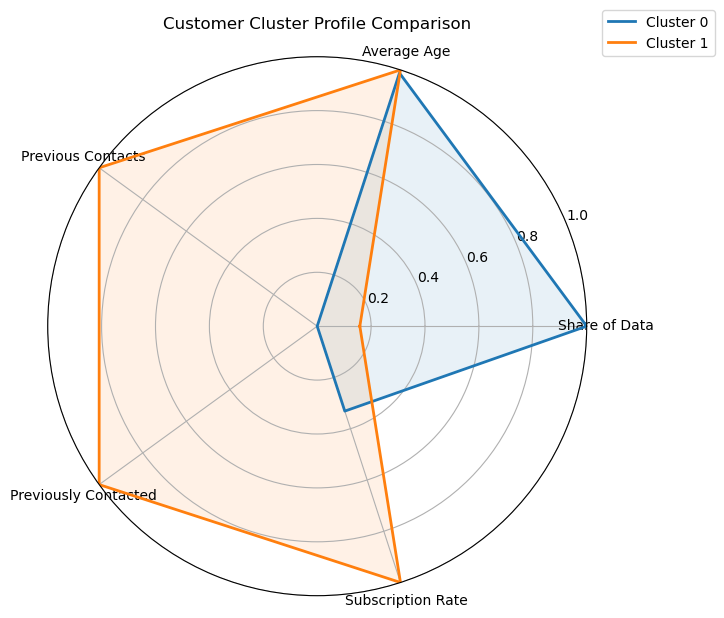

In [69]:
# Select interpretable measures from the profile table
radar_data = cluster_profile[[
    "Percentage_of_Data",
    "Avg_Age",
    "Avg_Previous_Contacts",
    "Previously_Contacted_Rate",
    "Subscription_Rate"
]].copy()

# Scale each measure relative to its maximum for radar-chart comparison
radar_scaled = radar_data.div(radar_data.max(axis=0))

labels = [
    "Share of Data",
    "Average Age",
    "Previous Contacts",
    "Previously Contacted",
    "Subscription Rate"
]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})

for cluster in radar_scaled.index:
    values = radar_scaled.loc[cluster].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster}")
    ax.fill(angles, values, alpha=0.10)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_title("Customer Cluster Profile Comparison", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))
plt.show()

The chart shows Cluster 0 contains most of the observations, while Cluster 1 shows substantially more previous campaign activity and a higher subscription rate. Average age is similar across the groups. Overall, the cluster separation is driven much more by previous campaign history than by demographic differences.

**Final Interpretation of Unsupervised Learning**

1. **How many clusters were selected?**  
K-Means solutions from 2 to 8 clusters were compared. The inertia curve did not show a clear elbow, so the silhouette score was used as the main guide. K = 2 had the highest silhouette score among the tested values (0.3581). This indicates some cluster structure, but not very strong separation.

2. **What do the two clusters look like?**  
Cluster 0 contains about 86.34% of the records and has an 8.83% subscription rate. Cluster 1 contains about 13.66% and has a higher 26.65% subscription rate. Average age is similar across the groups, while previous campaign activity differs substantially. The radar chart provides a visual summary of these profile differences.

3. **What mainly drives the separation?**  
The strongest pattern is previous campaign history. Cluster 0 contains the records with poutcome = nonexistent, while Cluster 1 contains records with a previous failure or success. Within Cluster 1, previous failures have a 14.23% historical subscription rate and previous successes have a much higher 65.11% rate.

4. **What is the business meaning?**  
The clustering confirms that previous campaign history is an important way to distinguish the records. However, the two clusters mostly reproduce information already contained in poutcome, so they should not be presented as completely new customer segments. The clustering is therefore used as exploratory and descriptive analysis. The supervised-learning stage is more useful for the main business objective because it combines multiple pre-call predictors to estimate subscription potential and rank contacts for targeting.

### **Supervised Machine Learning**



The unsupervised analysis showed that previous campaign history is a major source of structure in the customer data. However, the K-Means groups mainly reflect information already contained in poutcome, and clustering does not tell the bank which individual customer contacts should be prioritized.

Supervised learning is therefore used to predict the likelihood that a customer will subscribe to a term deposit using information available before the call is placed. The models learn from historical records where the final subscription outcome is known and use those patterns to score customer contacts.

The goal is not simply to classify customers as yes or no. The model score is especially useful because it allows customer contacts to be ranked from highest to lowest potential. This ranking can then be used to decide who should be contacted first and how far down the ranked list the bank should call.

**Questions Explored in This Section**

1. How well can term-deposit subscription be predicted before the call? - This determines whether customer, financial, previous-campaign, and economic information contains enough predictive value to support customer targeting.

2. Which classification model provides the strongest predictions? - Logistic Regression, Decision Tree, Random Forest, and XGBoost will be compared to determine which model provides the most useful subscription predictions.

3. How should the class imbalance be handled? - Only about 11.27% of recorded contacts resulted in a subscription. The analysis will therefore consider class imbalance when training and evaluating the models rather than relying mainly on overall accuracy.

4. Which customers have the highest predicted probability of subscribing? - The selected model will estimate a subscription probability for each customer contact. These probabilities will be used to rank customers from highest to lowest predicted potential.

5. What probability threshold should be used? - Instead of automatically classifying customers using the standard 0.50 probability threshold, different thresholds will be evaluated to understand the trade-off between identifying potential subscribers and making unnecessary calls.

6. Does model-based targeting perform better than random customer selection? - Lift and cumulative gains analysis will compare the ranked customer list with random customer selection to determine whether the model can identify more subscribers while contacting fewer customers.

7. How many customers should the bank contact? - Different calling depths will be evaluated using the ranked customer list. Business assumptions about the cost of making a call and the value of gaining a subscription will then be used to identify a practical calling cutoff.

**Business Purpose**

The purpose of supervised learning is not simply to build the model with the highest accuracy. Because most contacts do not result in a subscription, the analysis focuses on identifying and ranking higher-potential contacts so the bank can reduce unnecessary calls and use marketing resources more efficiently.

**Modeling**

**Train/Test Split**

Because only about 11.27% of contacts subscribed, we should use a stratified split so the subscriber/non-subscriber proportions remain similar in both sets.

In [70]:
# Create the predictor dataset by removing the target variable.
# The clustering label is also excluded because it was created
# during the unsupervised analysis and is not part of the
# original pre-call customer information.
X = df_model.drop(columns=["y"], errors="ignore")

# Create the target variable containing the binary
# subscription outcome for each customer contact.
y = df_model["y"]

# Split the data into 80% training data and 20% test data.
# stratify=y preserves the original subscriber/non-subscriber
# proportion in both the training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the number of observations in each dataset.
print("Training predictors:", X_train.shape)
print("Test predictors:", X_test.shape)

# Compare the subscription rate in the full dataset,
# training set, and test set to confirm that stratification
# preserved the original target distribution.
print(f"\nOverall subscription rate: {y.mean():.2%}")
print(f"Training subscription rate: {y_train.mean():.2%}")
print(f"Test subscription rate: {y_test.mean():.2%}")

Training predictors: (32940, 21)
Test predictors: (8236, 21)

Overall subscription rate: 11.27%
Training subscription rate: 11.27%
Test subscription rate: 11.27%


The dataset was divided into 32,940 training records (80%) and 8,236 test records (20%). The training data will be used to develop the models, while the test data will remain separate for final model evaluation.

The overall subscription rate is 11.27%, and the same rate is maintained in both the training and test sets. This confirms that the stratified split successfully preserved the original target distribution.

The modeling dataset contains both numerical and categorical predictors. Before training the classification models, numerical variables are standardized and categorical variables are converted to one-hot encoded features. The preprocessing steps are defined using the training data so that information from the test set is not used during model development.

**Model Preprocessing Pipeline**

In [71]:
# Prepare Predictors for Supervised Modeling
# Identify numerical predictors
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

# Identify categorical predictors, including Boolean variables
# such as the engineered previous-contact indicator
categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Create the preprocessing pipeline.
# Numerical variables are standardized so they are on comparable scales.
# Categorical variables are converted into binary indicator columns.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# Confirm that all predictors are included in preprocessing
print("Numerical predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))
print("Total predictors:", len(numeric_features) + len(categorical_features))
print("Duration included:", "duration" in X_train.columns)

Numerical predictors: 10
Categorical predictors: 11
Total predictors: 21
Duration included: False


All 21 pre-call predictors are included in the preprocessing pipeline, while duration remains excluded because it would not be available before the customer is contacted.

The preprocessing steps will later be combined with the classification models so that they are learned from the training data only. This helps prevent information from the test set from influencing model development.

### **Model Development with Cross-Validation and Hyperparameter Tuning**

Hyperparameter tuning tests different model configurations to determine which settings provide better predictive performance.

Because subscribers represent only 11.27% of the data, PR-AUC (average_precision) will be used as the primary tuning metric. Tuning will be performed using cross-validation on the training data only, so the test data does not influence parameter selection.

**Set Up Cross-Validation**

Stratification maintains approximately the same proportion of subscribers in each cross-validation fold.

In [72]:
# Use stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [73]:
# Hyperparameter Tuning for All Models
# Define the four classification models
models_to_tune = {

    "Logistic Regression": LogisticRegression(max_iter=1000,random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42,n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42,eval_metric="logloss",n_jobs=-1)}

# Define hyperparameters to test for each model
param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__class_weight": [None, "balanced"]},

    "Decision Tree": {
        "model__max_depth": [3, 5, 8, 12],
        "model__min_samples_split": [2, 10, 25],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"]},

    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_split": [2, 10, 20],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", "log2"],
        "model__class_weight": [None, "balanced"]},

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]}}

# Tune all models
tuning_results = []
best_models = {}

for model_name, model in models_to_tune.items():

    print(f"Tuning {model_name}...")

    # Combine preprocessing and the current model.
    pipeline = Pipeline([("preprocessor", preprocessor),("model", model)])

    # Use GridSearch for the smaller Logistic Regression
    # and Decision Tree search spaces.
    if model_name in ["Logistic Regression", "Decision Tree"]:

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            scoring="average_precision",
            cv=cv,
            n_jobs=-1
        )

    # Use RandomizedSearch for the larger Random Forest
    # and XGBoost search spaces to reduce computation time.
    else:

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grids[model_name],
            n_iter=20,
            scoring="average_precision",
            cv=cv,
            random_state=42,
            n_jobs=-1
        )

    # Perform tuning using the training data only.
    search.fit(X_train, y_train)

    # Save the best fitted version of each model.
    best_models[model_name] = search.best_estimator_

    # Save tuning results for comparison.
    tuning_results.append({
        "Model": model_name,
        "Best CV PR-AUC": search.best_score_,
        "Best Parameters": search.best_params_
    })

# Display tuning results
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df["Best CV PR-AUC"] = (
    tuning_results_df["Best CV PR-AUC"].round(4)
)

display(tuning_results_df)

Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning XGBoost...


,Model,Best CV PR-AUC,Best Parameters
0,Logistic Regression,0.4500,"{'model__C': 10, 'model__class_weight': None}"
1,Decision Tree,0.4207,"{'model__class_weight': None, 'model__max_dept..."
2,Random Forest,0.4684,"{'model__n_estimators': 200, 'model__min_sampl..."
3,XGBoost,0.4697,"{'model__subsample': 0.8, 'model__n_estimators..."


**

Hyperparameter tuning was performed using 5-fold stratified cross-validation on the training data, with PR-AUC used as the primary selection metric.

The tuned XGBoost model achieved the highest cross-validated PR-AUC of 0.4697, followed very closely by Random Forest at 0.4684. Logistic Regression achieved a PR-AUC of 0.4500, while Decision Tree produced the lowest score at 0.4207.

The results show that the ensemble tree-based models, particularly XGBoost and Random Forest, provide stronger performance for identifying the minority subscriber class. However, the difference between XGBoost and Random Forest is very small, so a final model should not be selected based only on the cross-validation results.

**Modeling Decision**

All four tuned models will next be evaluated on the unseen test set using the same performance metrics. This will show how well the tuned models generalize to new customer contacts.

The final model will be selected by considering PR-AUC, ROC-AUC, precision, recall, and F1-score, with particular attention to the model's ability to identify and rank potential subscribers.

**Tuned Model Comparison on Test Data**

We now evaluate the tuned models on the test data to determine how well they generalize.
Because subscription is imbalanced, model selection should not depend on accuracy alone. Precision, recall, F1, ROC-AUC, and PR-AUC will also be compared.

In [74]:
# Store test-set results for each tuned model
test_results = []

# Store probabilities so we can use them later
# for ranking, lift, gains, and business analysis.
test_probabilities = {}

# Evaluate every tuned model on the SAME unseen test set
for model_name, model in best_models.items():

    # Predict yes/no subscription using the default 0.50 threshold
    y_pred = model.predict(X_test)

    # Predict probability of subscription
    y_prob = model.predict_proba(X_test)[:, 1]

    # Save probabilities for later business analysis
    test_probabilities[model_name] = y_prob

    # Calculate evaluation metrics
    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

# Convert results into a comparison table
test_results_df = pd.DataFrame(test_results)

# Round metrics for easier interpretation
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

test_results_df[metric_columns] = (
    test_results_df[metric_columns].round(4)
)

# Sort primarily by PR-AUC
test_results_df = (
    test_results_df
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

display(test_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.9004,0.6598,0.2403,0.3523,0.8127,0.4902
1,XGBoost,0.8981,0.6233,0.2425,0.3491,0.8126,0.4847
2,Logistic Regression,0.8980,0.6438,0.2123,0.3193,0.8003,0.4540
3,Decision Tree,0.8986,0.6131,0.2716,0.3764,0.8038,0.4441


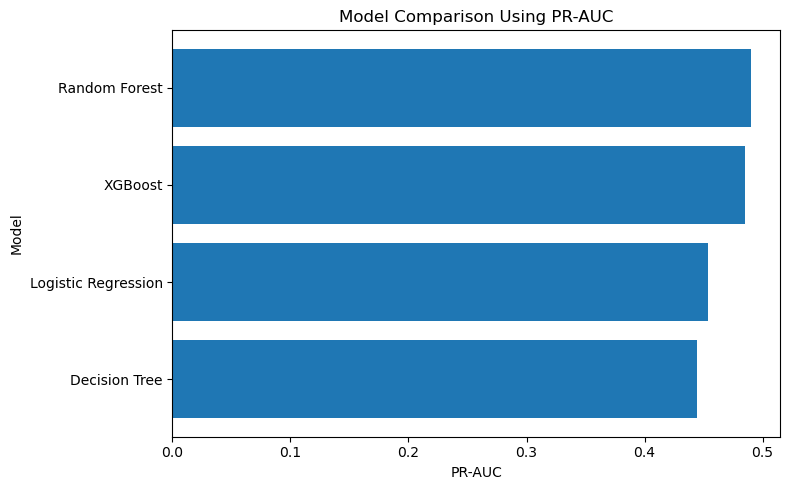

In [75]:
# Plot
# Compare tuned models using test PR-AUC
model_plot = (
    pd.DataFrame(test_results)
    .sort_values("PR-AUC", ascending=True))
plt.figure(figsize=(8, 5))
plt.barh(model_plot["Model"],model_plot["PR-AUC"])
plt.xlabel("PR-AUC")
plt.ylabel("Model")
plt.title("Model Comparison Using PR-AUC")
plt.tight_layout()
plt.show()

 

The tuned models were evaluated on the test data to measure their performance on unseen customer contacts.

Random Forest and XGBoost performed almost identically in overall ranking performance. Random Forest achieved a PR-AUC of 0.4902 and ROC-AUC of 0.8127, while XGBoost achieved a PR-AUC of 0.4847 and ROC-AUC of 0.8126. Random Forest also had higher precision (65.98%), while XGBoost had slightly higher recall (24.25% vs. 24.03%).

Decision Tree achieved the highest recall (27.16%) and F1-score (0.3764) at the default 0.50 classification threshold. However, its PR-AUC of 0.4441 was lower than the ensemble models, indicating weaker overall probability-ranking performance. Logistic Regression achieved a ROC-AUC of 0.8003 and PR-AUC of 0.4540.

### **Final Model Selection**

**Random Forest** is retained as the final model for customer ranking and business analysis. XGBoost had a slightly higher cross-validation PR-AUC (0.4697 vs. 0.4684), while Random Forest had a slightly higher test PR-AUC (0.4902 vs. 0.4847). Because the differences are small, the results should be interpreted as very similar rather than as a clear win for either model. Random Forest is used for the remaining analysis because of its strong test-set ranking performance and straightforward feature-importance analysis.

**Next Step**

The current classification results use the default probability threshold of 0.50. Because changing this threshold affects the trade-off between precision and recall, the next step will examine different thresholds before developing the final customer-targeting strategy.

### **Threshold Analysis on Random Forest**

After selecting Random Forest as the final model, different probability thresholds (0.10–0.50) are evaluated to understand the trade-off between precision and recall. This helps determine a suitable cutoff for classifying customers as likely subscribers.

In [76]:
final_model = best_models["Random Forest"]
# Predicted subscription probabilities
y_prob_final = final_model.predict_proba(X_test)[:, 1]

In [77]:
# Thresholds to evaluate
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into 0/1 predictions
    # using the selected threshold
    y_pred_threshold = (y_prob_final >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "Customers Predicted Positive": y_pred_threshold.sum()
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df[
    ["Precision", "Recall", "F1"]
] = threshold_results_df[
    ["Precision", "Recall", "F1"]
].round(4)

display(threshold_results_df)

,Threshold,Precision,Recall,F1,Customers Predicted Positive
0,0.1,0.3533,0.6789,0.4648,1783
1,0.2,0.4617,0.6099,0.5255,1226
2,0.3,0.5021,0.5054,0.5038,934
3,0.4,0.6042,0.3405,0.4356,523
4,0.5,0.6598,0.2403,0.3523,338


Lowering the classification threshold increased the model's ability to identify actual subscribers, but also reduced precision. At a threshold of 0.20, the model achieved the highest F1-score among the thresholds tested (0.5255), with 46.17% precision and 60.99% recall, identifying 1,226 contacts as potential subscribers.

Therefore, 0.20 provides the best F1-based classification trade-off among the thresholds tested. However, this is a classification threshold, not the final contact-depth decision. The number of contacts the bank should prioritize is evaluated separately using customer ranking, lift, cumulative gains, and resource-allocation analysis.

### **Customer Ranking, Lift, Gains And Resource Allocation**

### **How much better is model-based targeting than random customer selection?**

In [78]:
# Create a DataFrame containing the actual test outcomes
# and the predicted subscription probabilities from Random Forest.
ranking_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Probability": y_prob_final
})

# Rank customers from highest to lowest predicted probability.
# Customers at the top are those the model considers most likely to subscribe.
ranking_df = ranking_df.sort_values(
    "Predicted_Probability",
    ascending=False
).reset_index(drop=True)

# Total number of customers and actual subscribers in the test set
total_customers = len(ranking_df)
total_subscribers = ranking_df["Actual"].sum()

# Overall subscription rate represents random targeting performance.
overall_subscription_rate = ranking_df["Actual"].mean()

# Evaluate different percentages of the ranked customer list.
contact_depths = [0.10, 0.20, 0.30, 0.40, 0.50,
                  0.60, 0.70, 0.80, 0.90, 1.00]

lift_results = []

for depth in contact_depths:

    # Number of customers contacted at this depth
    n_contacted = int(total_customers * depth)

    # Select the highest-ranked customers
    targeted_customers = ranking_df.iloc[:n_contacted]

    # Count actual subscribers captured
    subscribers_captured = targeted_customers["Actual"].sum()

    # Subscription rate among contacted customers
    targeted_subscription_rate = (
        subscribers_captured / n_contacted
    )

    # Percentage of all actual subscribers captured
    cumulative_gain = (
        subscribers_captured / total_subscribers
    )

    # Lift compares model-based targeting with random targeting
    lift = (
        targeted_subscription_rate /
        overall_subscription_rate
    )

    lift_results.append({
        "Contact Depth": depth,
        "Customers Contacted": n_contacted,
        "Subscribers Captured": subscribers_captured,
        "Subscription Rate": targeted_subscription_rate,
        "Cumulative Gain": cumulative_gain,
        "Lift": lift
    })


# Convert results into a DataFrame
lift_df = pd.DataFrame(lift_results)


# Format percentage columns for easier interpretation
lift_df["Contact Depth"] = (
    lift_df["Contact Depth"] * 100
).round(0).astype(int)

lift_df["Subscription Rate"] = (
    lift_df["Subscription Rate"] * 100
).round(2)

lift_df["Cumulative Gain"] = (
    lift_df["Cumulative Gain"] * 100
).round(2)

lift_df["Lift"] = lift_df["Lift"].round(2)


# Rename columns so the output is business-friendly
lift_df = lift_df.rename(columns={
    "Contact Depth": "Contact Depth (%)",
    "Subscription Rate": "Subscription Rate (%)",
    "Cumulative Gain": "Subscribers Captured (%)"
})

display(lift_df)

# Show the number of calls avoided at the recommended top 20 % contact depth
print("Calls avoided at top 20%:", total_customers - int(total_customers * 0.20))

,Contact Depth (%),Customers Contacted,Subscribers Captured,Subscription Rate (%),Subscribers Captured (%),Lift
0,10,823,434,52.73,46.77,4.68
1,20,1647,614,37.28,66.16,3.31
2,30,2470,689,27.89,74.25,2.48
3,40,3294,742,22.53,79.96,2.00
4,50,4118,779,18.92,83.94,1.68
5,60,4941,815,16.49,87.82,1.46
6,70,5765,843,14.62,90.84,1.30
7,80,6588,871,13.22,93.86,1.17
8,90,7412,902,12.17,97.20,1.08
9,100,8236,928,11.27,100.00,1.00


Calls avoided at top 20%: 6589


**Customer Ranking, Lift & Gains:** The ranking analysis shows that the Random Forest model can identify potential subscribers much more efficiently than random targeting. By contacting only the top 10% of ranked customers (823 contacts), the bank would capture 434 of the 928 actual subscribers (46.77%), with a 4.68× lift over random targeting.

Expanding to the top 20% captures 66.16% of all subscribers with a 3.31× lift, while contacting the top 30% captures 74.25% with a 2.48× lift. As more customers are contacted, lift gradually decreases toward 1.0, showing that the model concentrates high-potential customers near the top of the ranked list.

**Lift Analysis plot**

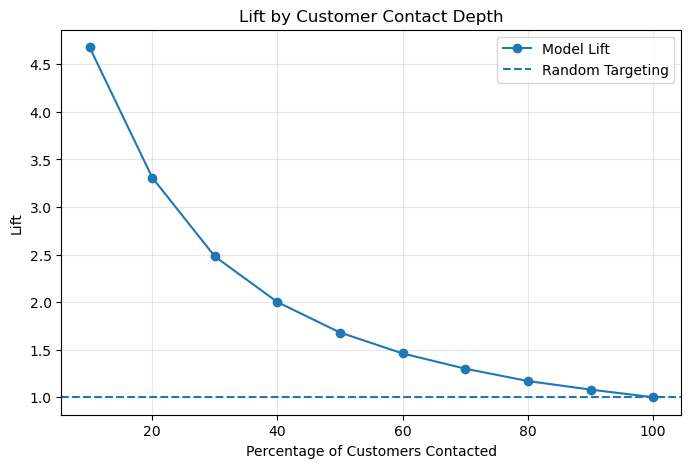

In [79]:
plt.figure(figsize=(8, 5))
# Plot lift at each contact depth
plt.plot(
    lift_df["Contact Depth (%)"],
    lift_df["Lift"],
    marker="o",
    label="Model Lift"
)

# A lift of 1 represents random targeting
plt.axhline(
    y=1,
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Percentage of Customers Contacted")
plt.ylabel("Lift")
plt.title("Lift by Customer Contact Depth")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

The lift plot shows that model-based targeting performs best near the top of the ranked list, with lift decreasing toward 1.0 as more contacts are included.

**Cumulative Gains Analysis**

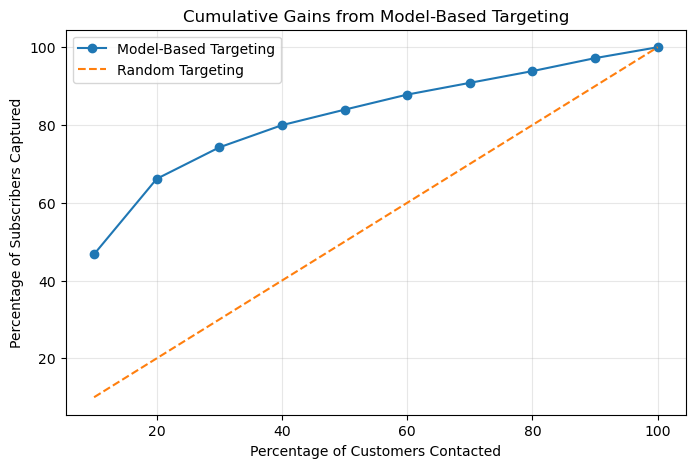

In [80]:
plt.figure(figsize=(8, 5))

# Plot the percentage of actual subscribers captured
plt.plot(
    lift_df["Contact Depth (%)"],
    lift_df["Subscribers Captured (%)"],
    marker="o",
    label="Model-Based Targeting"
)

# Random targeting baseline:
# contacting 10% randomly would be expected to capture
# approximately 10% of subscribers, 20% captures 20%, etc.
plt.plot(
    lift_df["Contact Depth (%)"],
    lift_df["Contact Depth (%)"],
    linestyle="--",
    label="Random Targeting"
)

plt.xlabel("Percentage of Customers Contacted")
plt.ylabel("Percentage of Subscribers Captured")
plt.title("Cumulative Gains from Model-Based Targeting")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

The cumulative gains plot shows that a large share of actual subscribers is concentrated near the top of the model-ranked contact list.

**Resource Allocation Senarios**

**How does the bank's targeting performance change when it contacts the top 10%, 20%, 30%, or more of the ranked customer list?**

Resource Allocation Recommendation:

The ranking analysis shows that the model concentrates potential subscribers near the top of the contact list. Contacting the Top 20% requires 1,647 calls while capturing 614 of the 928 subscribers in the test data, representing 66.16% subscriber capture and a 3.31× lift over random targeting. Increasing the contact depth from 20% to 30% requires approximately 823 additional calls but captures only 75 additional subscribers, indicating diminishing returns. Therefore, the Top 20% was selected as a practical, resource-efficient starting point rather than a financially optimal cutoff.

### **Model Explainability**

**Which factors were most important in predicting whether a customer would subscribe to a term deposit?**

In [81]:
# Access the fitted preprocessing step from the final pipeline
fitted_preprocessor = final_model.named_steps["preprocessor"]

# Access the fitted Random Forest model
fitted_rf = final_model.named_steps["model"]

# Get the feature names after preprocessing.
# Categorical variables have been expanded through one-hot encoding.
feature_names = fitted_preprocessor.get_feature_names_out()

# Get the importance score assigned to each transformed feature
feature_importance = fitted_rf.feature_importances_

# Combine feature names and importance scores
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Remove preprocessing prefixes such as "num__" and "cat__"
# to make the output easier to read
importance_df["Feature"] = (
    importance_df["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Sort features from highest to lowest importance
importance_df = (
    importance_df
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

# Display the 15 most important features
display(importance_df.head(15))

,Feature,Importance
0,euribor3m,0.152187
1,nr.employed,0.130213
2,days_since_previous_contact,0.078548
3,previously_contacted,0.075238
4,emp.var.rate,0.063085
5,cons.conf.idx,0.059527
6,poutcome_success,0.058020
7,age,0.050699
8,cons.price.idx,0.046117
9,campaign_capped,0.018508


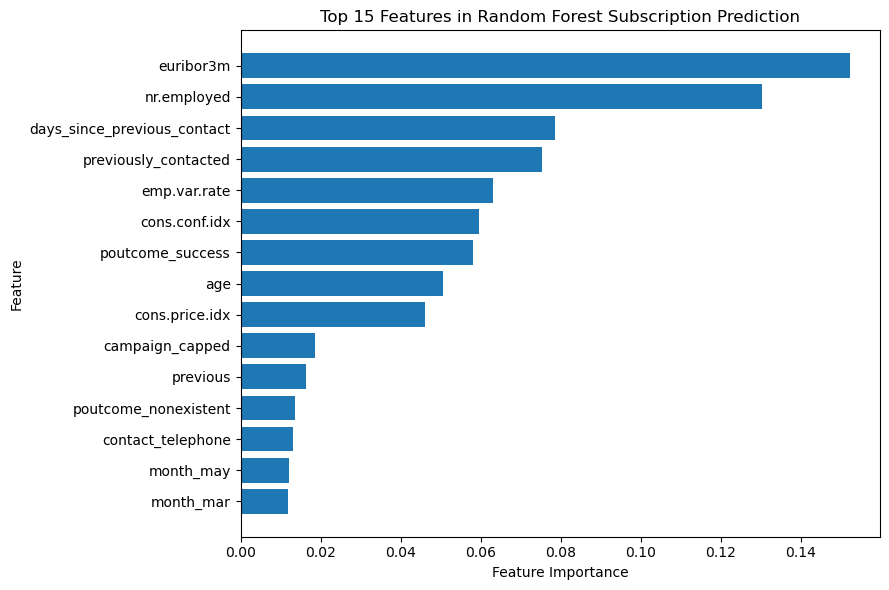

In [82]:
# Select the 15 most important features
top_features = (
    importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features in Random Forest Subscription Prediction")

plt.tight_layout()
plt.show()

Interpretation: The Random Forest relied most heavily on economic conditions and previous campaign information when ranking customers. euribor3m and nr.employed were the two most important features, followed by days_since_previous_contact, previously_contacted, and emp.var.rate. Previous campaign outcome was also important, particularly poutcome_success, which supports the earlier EDA finding that customers with a successful previous campaign outcome had a much higher subscription rate.

These importance scores show which variables the model relied on for prediction; they do not imply causality. Random Forest impurity-based importance can favor continuous or high-cardinality features, so the values should be treated as an indication of model reliance rather than a definitive measure of influence. In addition, days_since_previous_contact should be interpreted together with previously_contacted, because a zero value is used as a placeholder when no usable previous-contact date is recorded. The economic variables also partly reflect the period in which the call was made, so their importance should not be interpreted as a stable causal effect. This time-related information may also help explain why ranking performance was lower in the time-based validation. duration does not appear among the predictors, confirming that the final model uses information available before the current call.

**Business relevance**

The results suggest that the bank should consider both previous customer interactions and the broader economic environment when prioritizing customers. Because economic conditions can change over time, these signals should be monitored when the model is used for future campaigns.

### **Final Summary**

**Which factors are most associated with term-deposit subscription?**

Subscription behavior was associated with previous campaign experience, customer characteristics, contact conditions, and economic factors. Previous campaign success showed a particularly strong relationship with subscription during EDA. The final Random Forest model also identified euribor3m, nr.employed, days_since_previous_contact, previously_contacted, and poutcome_success among the most important predictors.

**Can customers be grouped into meaningful segments?**

K-Means produced two broad groups, but further profiling showed that the separation was mainly driven by poutcome. Cluster 0 contained records with no previous campaign outcome, while Cluster 1 contained records with a previous failure or success. The clustering is therefore useful as exploratory analysis, but it mostly reflects information already present in previous campaign history.

**How accurately can subscription be predicted before the call?**

Random Forest and XGBoost performed very similarly. XGBoost had a slightly higher cross-validation PR-AUC, while Random Forest had a slightly higher test PR-AUC. Random Forest achieved a test PR-AUC of 0.4902 and ROC-AUC of 0.8127 and was retained for the final ranking and business analysis.

**Which classification threshold provides the best balance?**

Among the thresholds tested, 0.20 produced the highest F1-score (0.5255), with 46.17% precision and 60.99% recall. This threshold is relevant when a binary subscriber/non-subscriber classification is required; it is separate from the Top 20% ranked-contact strategy.

**How much better is model-based targeting than random targeting?**

In the main random-split evaluation, contacting the top 10% of ranked customers captured 46.77% of actual subscribers with 4.68× lift, while the top 20% captured 66.16% with 3.31× lift.

**How far down the ranked customer list should the bank contact?**

Based on the main evaluation, the Top 20% provides a practical balance between subscriber capture and marketing effort. It requires 1,647 calls, captures 614 of 928 subscribers (66.16%), and avoids 6,589 calls compared with contacting the full test population. This is a resource-efficiency recommendation rather than a guaranteed or profit-maximizing cutoff.

**Final Recommendation**

The bank can use the Random Forest model to rank eligible contacts based on their predicted subscription potential. Based on the holdout test results, the Top 20% provides a practical resource-efficient starting point, capturing 66.16% of subscribers with a 3.31× lift while substantially reducing the number of calls required.

This recommendation is based on historical test-set performance and should not be interpreted as a guaranteed or profit-maximizing cutoff. Future campaigns should be monitored to determine whether model performance remains stable as customer behavior and economic conditions change.

### **Prepare Data for Streamlit Dashboard**

The dashboard will focus on actionable results.

In [83]:
# Start with the original test-set customer information
dashboard_df = X_test.copy().reset_index(drop=True)

# Add the actual subscription outcome
dashboard_df["Actual_Subscription"] = y_test.reset_index(drop=True)

# Add the Random Forest predicted subscription probability
dashboard_df["Predicted_Probability"] = y_prob_final

# Rank customers from highest to lowest predicted probability
dashboard_df = (
    dashboard_df
    .sort_values("Predicted_Probability", ascending=False)
    .reset_index(drop=True)
)

# Create a customer rank
dashboard_df["Customer_Rank"] = (
    dashboard_df.index + 1
)

# Calculate each customer's percentile position in the ranked list
dashboard_df["Rank_Percentage"] = (
    dashboard_df["Customer_Rank"] / len(dashboard_df) * 100
)

# Flag customers included in the recommended top 20%
dashboard_df["Recommended_Contact"] = (
    dashboard_df["Rank_Percentage"] <= 20
)

# Display the highest-ranked customers
display(
    dashboard_df[
        [
            "Customer_Rank",
            "Predicted_Probability",
            "Recommended_Contact",
            "Actual_Subscription"
        ]
    ].head(10)
)

,Customer_Rank,Predicted_Probability,Recommended_Contact,Actual_Subscription
0,1,0.869543,True,1
1,2,0.868428,True,1
2,3,0.866923,True,1
3,4,0.866600,True,1
4,5,0.866103,True,1
5,6,0.863362,True,1
6,7,0.854427,True,1
7,8,0.853346,True,1
8,9,0.850206,True,1
9,10,0.846019,True,1


**Save the dashboard files**

Three CSV files are created to connect the modeling results to the Streamlit dashboard. The customer priority file provides ranked contacts and model scores, the contact-depth file summarizes subscriber capture and lift at different targeting levels, and the feature-importance file shows the main factors used by the model. These files allow the dashboard to present the model results as practical marketing decisions without retraining the model.

In [84]:
# Save customer-level ranking results
dashboard_df.to_csv(
    "customer_priority_dashboard.csv",
    index=False
)

# Save the contact-depth results used for
# lift, gains, and resource-allocation displays
lift_df.to_csv(
    "contact_depth_analysis.csv",
    index=False
)

# Save model feature importance
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("Dashboard files created successfully.")

Dashboard files created successfully.


# **Technical Rationale**

### **Modeling Objective and Overall Approach**

The goal of the modeling work was not simply to classify customers as subscribers or non-subscribers. The larger objective was to build a model that could estimate each customer's probability of subscribing before a marketing call is made. These probabilities could then be used to rank customers and help the bank decide who should be contacted first when marketing resources are limited.

The analysis therefore combined both unsupervised and supervised learning. K-Means clustering was used to explore whether meaningful customer segments existed, while supervised classification models were used to predict individual subscription probability. After model selection, threshold analysis, customer ranking, lift, cumulative gains, and contact-depth analysis were used to translate model predictions into a practical targeting strategy.

### **Data Preparation and Leakage Prevention**

Data preparation focused on making the dataset suitable for a realistic pre-call prediction problem. One of the most important decisions was to exclude duration. Call duration is strongly related to subscription, but it is only known after a call has taken place. Including it would create data leakage because the model would be using information that would not be available when the bank decides whom to contact.

The pdays variable also required special treatment because the value 999 represents customers who had not previously been contacted rather than an actual number of days. This information was separated into variables such as previously_contacted and days_since_previous_contact. Values originally recorded as unknown were generally retained as a separate category rather than removed or imputed. Two extremely small categories were consolidated during feature engineering: default = yes was combined with unknown, and education = illiterate was combined with basic.4y. Additional features, including age_group and campaign_capped, were created to represent useful customer and campaign information more clearly.

Categorical variables were one-hot encoded, while numerical variables were standardized within the preprocessing pipeline. The train/test split was stratified so that the approximately 11.27% subscription rate remained consistent across the training and test sets.

### **Customer Segmentation**

K-Means clustering was included as an exploratory step to determine whether customers could be separated into meaningful groups based on customer characteristics and previous campaign activity. Values of k from 2 through 8 were compared using the elbow method and silhouette score. A two-cluster solution produced the highest silhouette score among the values tested.

The clustering analysis revealed two groups. The larger cluster represented approximately 86% of the observations and had an 8.83% subscription rate, while the smaller cluster represented approximately 14% and had a 26.65% subscription rate. The cluster separation aligned directly with previous campaign history: the larger cluster contained observations with no previous campaign outcome (poutcome = nonexistent), while the smaller cluster contained observations with a recorded previous campaign outcome (failure or success). Within the smaller cluster, customers whose previous campaign succeeded subscribed at 65.1%, compared with 14.2% for those whose previous campaign failed.

This analysis was useful for understanding broad customer patterns, but clustering alone does not provide an individual subscription probability. For that reason, clustering was treated as descriptive supporting analysis rather than the primary targeting method.

### **Classification Models Considered**

Four supervised classification approaches were evaluated: Logistic Regression, Decision Tree, Random Forest, and XGBoost. These models were selected because they provide different levels of complexity and interpretability.

Logistic Regression provided a useful linear benchmark and helped determine how well a relatively simple model could separate subscribers from non-subscribers. Decision Tree provided an interpretable nonlinear alternative. Random Forest was evaluated because combining many trees can capture nonlinear relationships and interactions while reducing the instability of a single tree. XGBoost was included as a more advanced boosting approach capable of modeling complex patterns.

Rather than selecting a model based on a single default configuration, hyperparameter tuning was combined with five-fold stratified cross-validation on the training data. Grid search was used for Logistic Regression and Decision Tree, while randomized search was used for the larger Random Forest and XGBoost search spaces.

### **Model Selection and Evaluation**

Because only 11.27% of observations were subscribers, accuracy alone was not considered an appropriate model-selection measure. A model predicting most customers as non-subscribers could achieve high accuracy without being useful for targeting. Therefore, PR-AUC was used as the primary model-selection metric, with ROC-AUC, precision, recall, and F1-score providing additional information.

Random Forest and XGBoost performed almost identically. XGBoost had a slightly higher cross-validation PR-AUC (0.4697 vs. 0.4684), while Random Forest had a slightly higher test PR-AUC (0.4902 vs. 0.4847). Random Forest achieved a test ROC-AUC of 0.8127 compared with 0.8126 for XGBoost. Random Forest was retained for the final ranking and business analysis because of its strong test-set ranking performance and straightforward feature-importance analysis, not because it clearly outperformed XGBoost.

This distinction was important because the business problem depends more on ranking high-potential customers correctly than on assigning every customer a fixed yes/no classification.

### **Threshold and Ranking Analysis**

The default classification threshold of 0.50 was not automatically assumed to be the best business threshold. Thresholds between 0.10 and 0.50 were compared using precision, recall, and F1-score. Among the tested values, a 0.20 threshold produced the highest F1-score of 0.5255, with 46.17% precision and 60.99% recall.

However, the final marketing strategy was not based only on this classification threshold. Predicted probabilities were used to rank customers from highest to lowest likelihood of subscription. This approach better reflects how a bank would operate when it has a limited number of calls available.
Lift and cumulative gains analysis showed that the model concentrated many actual subscribers near the top of the ranked list. The top 10% captured 46.77% of subscribers with a 4.68× lift, while the top 20% captured 66.16% with a 3.31× lift.

### **Resource Allocation Decision**

Different contact depths were compared to understand the trade-off between marketing effort and subscriber capture. Contacting the top 20% required 1,647 calls and captured 614 of the 928 subscribers in the test data. This represents 66.16% of subscribers while avoiding 6,589 calls compared with contacting the full test population.

Increasing the contact depth to 30% required approximately 823 additional calls but captured only 75 additional subscribers. This demonstrates diminishing returns as the bank moves further down the ranked customer list.

For this reason, the top 20% was selected as a practical, resource-efficient contact depth. It should not be interpreted as a mathematically optimal or profit-maximizing cutoff because actual call costs and the financial value of a successful term-deposit subscription were not available in the dataset. The recommendation is therefore based on the observed trade-off between subscriber capture, lift, and the number of calls required.

### **Model Explainability**

Random Forest feature importance was examined to understand which variables contributed most to the model's predictions. The strongest predictors included euribor3m, nr.employed, days_since_previous_contact, previously_contacted, emp.var.rate, cons.conf.idx, and poutcome_success.

An important observation is that the model relies on both economic conditions and previous campaign information, rather than only customer demographics. The economic indicators (euribor3m, nr.employed, emp.var.rate, and cons.conf.idx) also partly reflect the period in which each call was made, so their importance may reflect timing as well as customer behavior. Because these economic variables change over time, future time-based validation would be useful for determining whether their predictive value remains stable across later campaign periods.

Feature importance should not be interpreted as evidence of causality. Random Forest impurity-based importance can favor continuous or high-cardinality features, and days_since_previous_contact should be interpreted together with previously_contacted because zero is used as a placeholder when no usable previous-contact date is recorded. A variable receiving high importance means that it was useful to the Random Forest for making predictions; it does not mean that changing that variable would cause a customer to subscribe.

### **Known Limitations**

Several limitations should be considered before using the model operationally. First, the analysis is based on historical campaign data, so future customer behavior may change as economic conditions, customer preferences, and marketing practices change. The model should therefore be monitored for performance drift.

Second, the dataset represents recorded marketing contacts rather than necessarily unique customers. This limits the ability to interpret every row as an independent individual customer.

Third, the recommended 20% contact depth is based on retrospective test-set performance. It demonstrates what the ranking strategy would have achieved on the holdout data, but it does not guarantee the same result in a future campaign.

Finally, the current resource-allocation analysis does not include actual financial information such as cost per call, expected deposit value, customer lifetime value, or campaign profit. The recommended contact depth therefore represents a resource-efficiency decision rather than a formal profit-maximizing solution.

### **Recommended Next Steps**

The next step would be to test the targeting strategy in a prospective campaign or controlled A/B experiment. A model-targeted group could be compared with the bank's existing targeting approach or a randomly selected group to determine whether model-based targeting improves campaign performance.

Time-based validation could also be performed by training the model on earlier campaign records and testing it on later records. This would help determine whether model performance remains stable as customer behavior and economic conditions change over time. The model should also be monitored and periodically retrained as new campaign data becomes available.

If actual financial information becomes available, such as the cost per contact and value of a successful subscription, the contact-depth analysis could be extended to identify the contact depth that maximizes expected campaign value rather than selecting the Top 20% primarily based on subscriber capture, lift, and marketing effort.

### **Future Technical Enhancements**

Several extensions could strengthen the analysis beyond the current project. More advanced explainability methods such as SHAP could provide both global and customer-level explanations for individual predictions. Probability calibration could improve the interpretation of predicted probabilities, while additional temporal validation across multiple campaign periods could provide a more complete assessment of performance stability over time.

A further extension would be uplift modeling. The current model predicts which customers are likely to subscribe, but it does not determine whether the marketing call itself changes their likelihood of subscribing. With appropriate treatment and control data, uplift modeling could help distinguish customers who are likely to subscribe because of the campaign from customers who may subscribe regardless.

The strongest future version of the system would therefore move from “Who is most likely to subscribe?” toward “Who should the bank contact to generate the greatest incremental business value?” This would combine predictive modeling, causal experimentation, and campaign economics into a more complete decision-support system.